<a href="https://colab.research.google.com/github/mfachriridwan/claude/blob/main/MSW_pathway_model_v3/MSW_Single_City_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSW recovery pathways: analysis for ONE city (v3.2)
*Analisis jalur pengolahan sampah untuk SATU kota*

This notebook reproduces the screening model of the article for **one city or regency** whose data you enter yourself,
either in the template (`templates/single_city_template.xlsx` or the three CSV files) or directly in Step 1.
It compares six options per tonne of mixed MSW at the facility gate in 2025:

| Code | Option |
|---|---|
| SL | Sanitary landfill with gas collection and flare |
| S1 | Waste-to-energy (grate incineration) |
| S2 | RDF co-processed in the nearest cement kiln |
| S3 | Anaerobic digestion (AD) of food waste |
| S4 | PHB bioplastic from landfill gas |
| S5 | Integrated RDF + AD |

**Ex-ante decision support.** The facilities need not exist: the results show which options merit a feasibility study
under your conditions, what they must achieve to beat a landfill, and which local data are worth collecting first.

| Step | Output |
|---|---|
| 0 | Setup (about 1 minute) |
| 1 | Your data: template upload, typed input, or the Kota Padang example |
| 2 | Waste characteristics and feasibility gates |
| 3 | Central results: GHG, cost, fossil energy, land |
| 4 | Decision at fixed carbon values, with Monte Carlo uncertainty |
| 5 | Uncertainty and the inputs that drive it |
| 6 | Scenarios and stress tests |
| 7 | Break-even targets against the landfill |
| 8 | Value of information: what to measure first |
| 9 | Projection to 2045 against 2025 (grid to net zero in 2060, real cost escalation) |
| 10 | Download the reports (Excel + figures) |

## Step 0. Setup / Persiapan

In [1]:
import os, sys, subprocess, pathlib
REPO_URL = "https://github.com/mfachriridwan/claude.git"
BRANCH = "main"            # branch that contains the MSW_pathway_model_v3 folder
IN_COLAB = "google.colab" in sys.modules

def _here(p): return pathlib.Path(p, "mswpath").exists()
if not _here("."):
    if _here("MSW_pathway_model_v3"):
        os.chdir("MSW_pathway_model_v3")
    elif IN_COLAB:
        r = subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCH, REPO_URL, "repo"])
        if r.returncode == 0 and _here("repo/MSW_pathway_model_v3"):
            os.chdir("repo/MSW_pathway_model_v3")
        else:   # private repository or no network: upload the release ZIP instead
            from google.colab import files
            print("Clone failed. Upload MSW_v3_results.zip / Gagal clone, unggah file ZIP:")
            up = files.upload(); z = next(iter(up))
            subprocess.run(["unzip", "-q", "-o", z]); os.chdir("MSW_pathway_model_v3")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Image
from mswpath import MSWModel, PW, NAMES, CARBON_VALUES, __version__
from mswpath import single as S
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
OUT = pathlib.Path("outputs/single_city"); OUT.mkdir(parents=True, exist_ok=True)
print("mswpath", __version__, "| working directory:", os.getcwd())

mswpath 3.2.0 | working directory: /home/user/claude/MSW_pathway_model_v3


## Step 1. Your data / Data Anda
Choose **one** input mode / pilih **satu** cara input:

* `"example"`: the Kota Padang RIPS data (reproduces the worked example of the article);
* `"upload"`: fill in `templates/single_city_template.xlsx` (or the three CSV files `single_city_city_data.csv`,
  `single_city_composition.csv`, `single_city_local_parameters.csv`) and upload it;
* `"typed"`: type the values in the next cell.

In the template: yellow cells are inputs, grey cells are the Padang example. **Leave a composition cell blank if the
category is not reported** (blank is not zero). Optional sheet `local_parameters`: your own measured or local values
(e.g. moisture of food waste, landfill cost, RDF price) replace the model defaults.

In [2]:
INPUT_MODE = "example"          # "example", "upload" or "typed"

if IN_COLAB and INPUT_MODE == "upload":
    from google.colab import files
    files.download("templates/single_city_template.xlsx")
    print("Fill in the template, then upload the .xlsx (or the 2-3 CSV files) / Isi template lalu unggah:")
    up = files.upload()
    names = list(up)
    xlsx = [n for n in names if n.lower().endswith(".xlsx")]
    if xlsx:
        cd, comp, par = S.read_template(xlsx[0])
    else:
        pick = lambda key: next((n for n in names if key in n), None)
        cd, comp, par = S.read_template(city_csv=pick("city_data"), comp_csv=pick("composition"),
                                        par_csv=pick("local_parameters"))
elif INPUT_MODE == "upload":     # outside Colab: put your file next to this notebook and give its name here
    cd, comp, par = S.read_template("templates/single_city_example_kota_padang.xlsx")
elif INPUT_MODE == "example":
    cd, comp, par = S.read_template("templates/single_city_example_kota_padang.xlsx")

**Typed input** (used only when `INPUT_MODE = "typed"`). Values below are Kota Padang; replace them with yours.
`None` = not reported / not known.

In [3]:
MY_CITY = dict(
    city_name='Kota Padang', province='Sumatera Barat',
    grid_region='Sumatera',              # Jamali, Sumatera or Mahakam
    tonnage_total_tpd=647.57,            # t/day, wet, domestic + non-domestic
    tonnage_nondomestic_tpd=26.84,       # part of the total (None = not separated)
    tonnage_year=2023, growth_rate=0.0065,   # growth as a fraction per year (None = 1.73%/yr default)
    composition_year=2023, organik_lumped='no',
    lat=-0.9492, lon=100.3543,           # planned site; or give kiln_road_km instead
    kiln_road_km=None,
    managed_share=0.7182, managed_share_definition='waste delivered to the TPA / generation (lower bound; provisional)',
    source='RIPS Kota Padang (domestic and non-domestic composition)',
    monte_carlo_draws=4000, random_seed=20251)
#                 category: (domestic %, non-domestic %)
MY_COMPOSITION = {
    'sisa_makanan': (43.95, 51.56),
    'daun_kering': (15.68, 25.78),
    'kertas_kardus': (8.85, 6.34),
    'kayu': (0.42, 0.26),
    'plastik': (19.84, 9.61),
    'logam': (1.3, 1.36),
    'kain': (1.8, 0.93),
    'karet_kulit': (0.27, 0.26),
    'sterofoam': (0.22, 0.54),
    'b3': (0.18, 0.33),
    'elektronik': (1.09, 0.17),
    'lain_lain': (6.41, 2.85),
    'kaca': (None, None),
}
#                 parameter key: (your central, your low, your high, source)   -- optional, see templates
MY_PARAMETERS = {}   # e.g. {"moisture_food": (0.78, 0.72, 0.84, "own sampling 2025"), "c_sl": (15, 10, 22, "DLH budget")}

if INPUT_MODE == "typed":
    M0 = MSWModel("data")
    cd, comp, par = S.blank_template(M0)
    cd["value"] = cd.field.map({k: ("" if v is None else v) for k, v in MY_CITY.items()}).fillna("")
    comp["domestic_pct"] = comp.category.map({k: v[0] for k, v in MY_COMPOSITION.items()})
    comp["nondomestic_pct"] = comp.category.map({k: v[1] for k, v in MY_COMPOSITION.items()})
    for k, (c_, lo, hi, src) in MY_PARAMETERS.items():
        par.loc[par.key == k, ["your_central", "your_low", "your_high", "your_source"]] = [c_, lo, hi, src]

### Validation and harmonisation / Validasi
The 2025 tonnage is projected **once**: $Q_{2025} = Q_t\,(1+g)^{2025-t}$. Each stream's composition is normalised to
100% and weighted by its 2025 tonnage. Errors stop the run; warnings list every assumption applied.

In [4]:
settings = {r.field: r.value for r in cd.itertuples()}
N = int(pd.to_numeric(settings.get("monte_carlo_draws"), errors="coerce") or 4000) if str(settings.get("monte_carlo_draws")).strip() not in ("", "nan") else 4000
SEED = int(float(settings.get("random_seed"))) if str(settings.get("random_seed")).strip() not in ("", "nan") else 20251
M = MSWModel("data", seed=SEED)                      # fresh model: defaults from data/*.csv
raw, errors, warnings = S.to_input(cd, comp, M)
print("Errors / Galat:", errors or "none")
for w in warnings: print("Warning / Peringatan:", w)
if errors: raise SystemExit("Fix the errors in the template and run this cell again.")
changed = S.apply_local_parameters(M, par)
print("\nLocal parameter values used / Nilai parameter lokal:"); display(changed if len(changed) else "none (all defaults)")
display(comp.set_index("category")[["label_en", "model_fraction", "domestic_pct", "nondomestic_pct"]])
print(f"Monte Carlo draws: {N:,}; random seed: {SEED}")

Errors / Galat: none
Warning / Peringatan: not reported (zero share, modelling assumption): kaca
Warning / Peringatan: 2025 tonnage = 647.6 x (1 + 0.0065)^2 = 656.0 t/day (projected once)

Local parameter values used / Nilai parameter lokal:


'none (all defaults)'

,label_en,model_fraction,domestic_pct,nondomestic_pct
category,,,,
sisa_makanan,food waste,food,43.95,51.56
daun_kering,garden/leaves,garden,15.68,25.78
kertas_kardus,paper and cardboard,paper,8.85,6.34
kayu,wood,wood,0.42,0.26
plastik,plastics,plastic,19.84,9.61
logam,metals,metal,1.30,1.36
kain,textiles,textile,1.80,0.93
karet_kulit,rubber and leather,rubber,0.27,0.26
sterofoam,styrofoam,plastic,0.22,0.54


Monte Carlo draws: 4,000; random seed: 20251


## Running the analysis / Menjalankan analisis (about 10-30 s)

In [5]:
A = S.analyse(M, raw, N=N)
FIGS = S.figures(A, M, OUT)
print(f"{A['city']}: 2025 tonnage {A['Q2025']:,.1f} t/day")

Kota Padang: 2025 tonnage 656.0 t/day


## Step 2. Waste characteristics and feasibility gates / Karakteristik sampah
Moisture $M=\sum_j s_j w_j$, lower heating value as received $H=\sum_j s_j h_j (1-w_j) - \lambda M$, methane
potential $L_0$ (IPCC DOC on a dry basis $\times$ DOCf). Gates: WtE needs LHV $\ge$ 7 MJ/kg and $\ge$ 150 t/day;
the Perpres 109/2025 tariff needs $\ge$ 1,000 t/day; RDF needs NCV $\ge$ 12.56 MJ/kg and a kiln within 300 km; PHB
needs $\ge$ 500 t/yr.

city,value
Q_2025,656.01577
moisture,0.521339
LHV,7.193863
L0_sl,45.773424
wte_kwh,359.693151
rdf_yield,0.260531
rdf_ncv,18.063841
kiln,Semen Padang (Indarung)
road_km,16.795224
gate_LHV,True


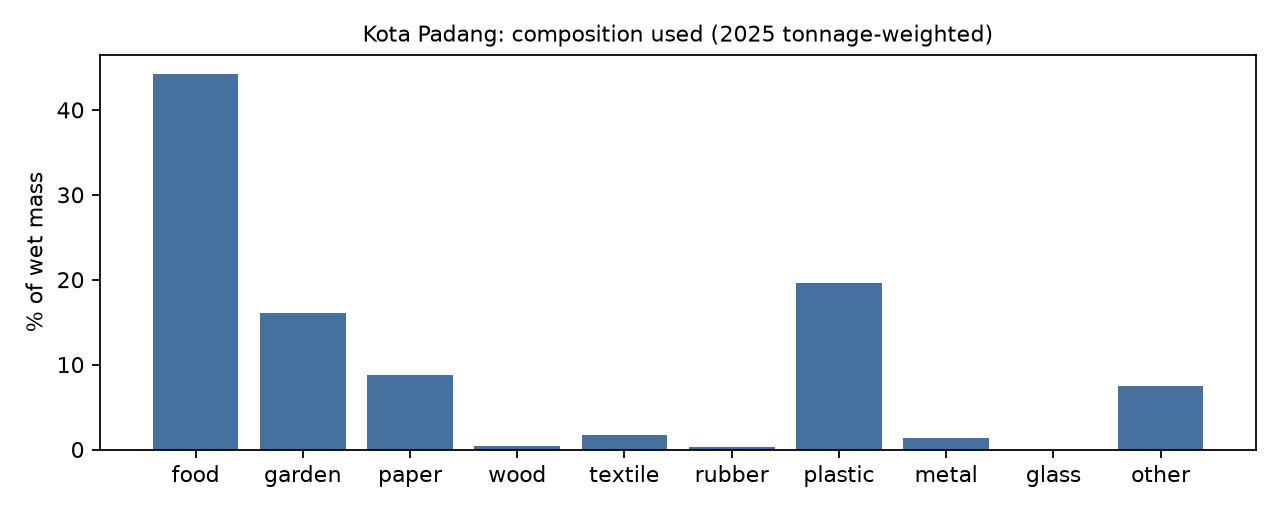

In [6]:
keys = ["Q_2025", "moisture", "LHV", "L0_sl", "wte_kwh", "rdf_yield", "rdf_ncv", "kiln", "road_km", "gate_LHV",
        "gate_WtE_scale", "gate_PSEL_generated", "gate_RDF", "gate_PHB"]
display(A["char"].loc[[k for k in keys if k in A["char"].index]])
display(Image(str(FIGS["composition"])))

## Step 3. Central results per tonne / Hasil nilai tengah per ton
GHG in kg CO$_2$e/t (GWP100, AR6), net levelised cost in USD/t, fossil cumulative energy demand in MJ/t (negative =
saving), land take in m²/t. Abatement cost against the landfill: $MAC = 10^3 (C_k - C_{SL})/(G_{SL} - G_k)$.

,option,passes_gates,GHG_kgCO2e_t,avoided_vs_open_dump,avoided_vs_landfill,net_cost_USD_t,abatement_cost_vs_landfill_USD_tCO2e,fossil_CED_MJ_t,land_m2_t
SL,Sanitary landfill + flare,True,561.15,428.56,0.00,18.44,NaN,77.60,0.08
S1,WtE,True,159.55,830.16,401.60,57.91,98.29,-4195.68,0.02
S2,RDF,True,345.38,644.33,215.77,38.74,94.09,-3857.64,0.06
S3,AD,True,389.49,600.22,171.66,36.57,105.63,-196.71,0.07
S4,PHB,True,547.22,442.49,13.93,38.07,1409.63,-580.02,0.08
S5,RDF + AD,True,179.68,810.02,381.47,44.83,69.19,-4302.90,0.04


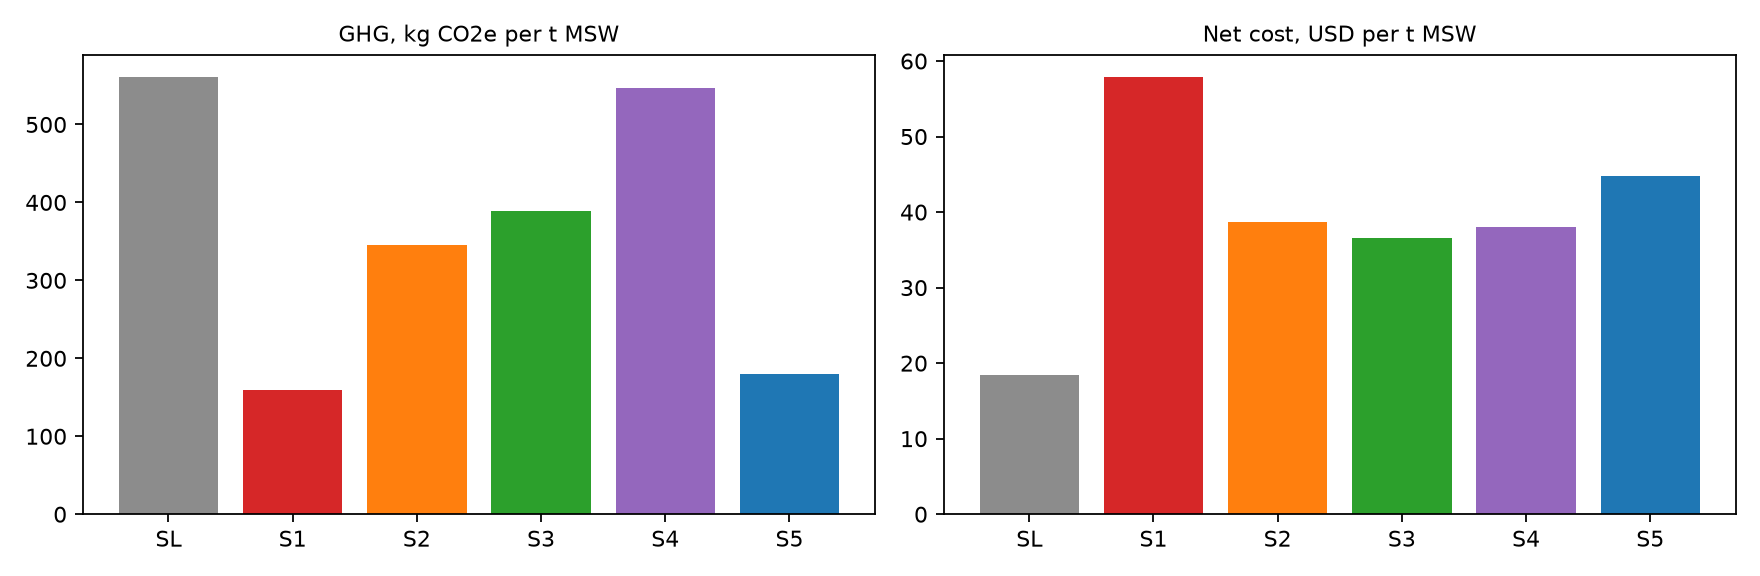

In [7]:
display(A["central"].round(2))
display(Image(str(FIGS["central"])))

## Step 4. Decision at fixed carbon values / Keputusan pada nilai karbon tetap
The best option has the lowest **carbon-inclusive cost** $CIC_k = C_k + p\,G_k/1000$ (USD/t) among the options that
pass their gates. The carbon value $p$ is a policy choice, so it is fixed (2 USD/t = Indonesian carbon tax, UU 7/2021).
$P(\text{best})$ is the share of Monte Carlo draws in which an option wins, with its standard error
$\sqrt{P(1-P)/N}$. A small lead means the choice depends on uncertain inputs (decision uncertainty), not on noise.

carbon_value,0,2,25,50,100
option,,,,,
SL,0.958 ± 0.006,0.958 ± 0.006,0.95 ± 0.007,0.795 ± 0.013,0.197 ± 0.012
S1,0.0 ± 0.0,0.0 ± 0.0,0.003 ± 0.002,0.043 ± 0.006,0.116 ± 0.01
S2,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.001,0.012 ± 0.003,0.006 ± 0.002
S3,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.002 ± 0.001,0.006 ± 0.002
S4,0.042 ± 0.006,0.042 ± 0.006,0.046 ± 0.006,0.047 ± 0.007,0.02 ± 0.004
S5,0.0 ± 0.0,0.0 ± 0.0,0.001 ± 0.001,0.102 ± 0.009,0.653 ± 0.015


Best option at central values, by carbon value:


,0
city,Kota Padang
Q,656.01577
best_at_0,SL
best_at_25,SL
best_at_50,SL
best_at_100,S5


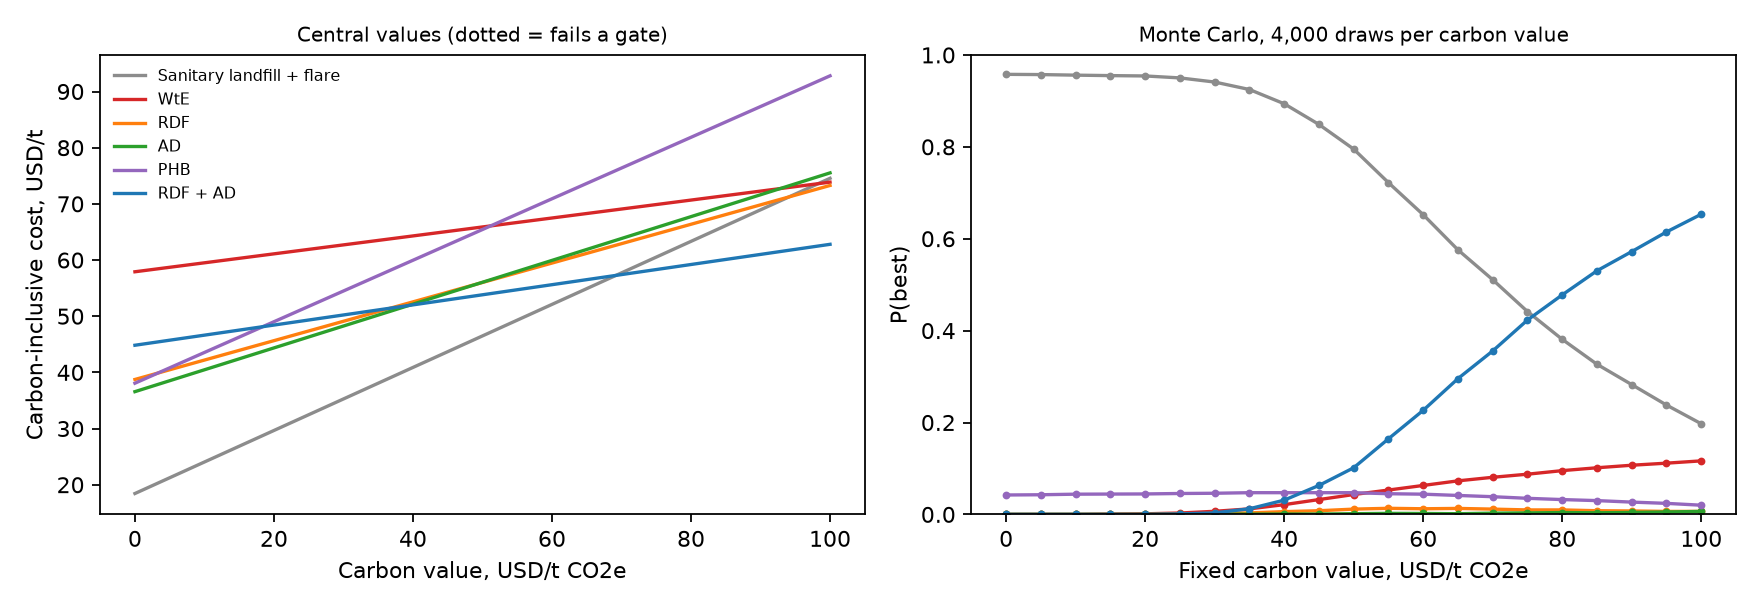

In [8]:
pf = A["p_fixed"].assign(value=lambda d: d.p_best.round(3).astype(str) + " ± " + (1.96 * d.se).round(3).astype(str))
display(pf.pivot(index="option", columns="carbon_value", values="value").reindex(PW))
print("Best option at central values, by carbon value:"); display(A["best_central"])
display(Image(str(FIGS["decision"])))

## Step 5. Uncertainty and its drivers / Ketidakpastian dan pemicunya

,G_p5,G_p50,G_p95,C_p5,C_p50,C_p95,dG_SL_p5,dG_SL_p50,dG_SL_p95,CED_p5,CED_p50,CED_p95,LU_p5,LU_p50,LU_p95,p_feasible
pathway,,,,,,,,,,,,,,,,
SL,331.1,588.9,922.3,11.4,18.2,24.6,0.0,0.0,0.0,48.5,87.8,136.2,0.1,0.1,0.1,1.0
S1,67.4,177.7,313.5,44.1,63.0,84.8,97.2,407.6,790.9,-5744.8,-3920.7,-2508.1,0.0,0.0,0.0,0.6
S2,187.2,362.8,577.0,31.8,39.1,46.6,104.6,225.1,393.2,-5668.4,-3830.5,-2386.3,0.0,0.1,0.1,1.0
S3,224.4,406.7,664.4,30.9,39.0,47.6,88.7,173.8,298.2,-453.0,-139.6,83.9,0.0,0.1,0.1,1.0
S4,314.0,575.2,911.1,17.6,36.0,60.9,5.0,13.4,27.2,-828.7,-455.6,-186.3,0.1,0.1,0.1,1.0
S5,79.5,189.7,330.9,39.1,47.5,56.5,220.7,396.5,631.1,-6106.3,-4253.8,-2817.6,0.0,0.0,0.1,1.0


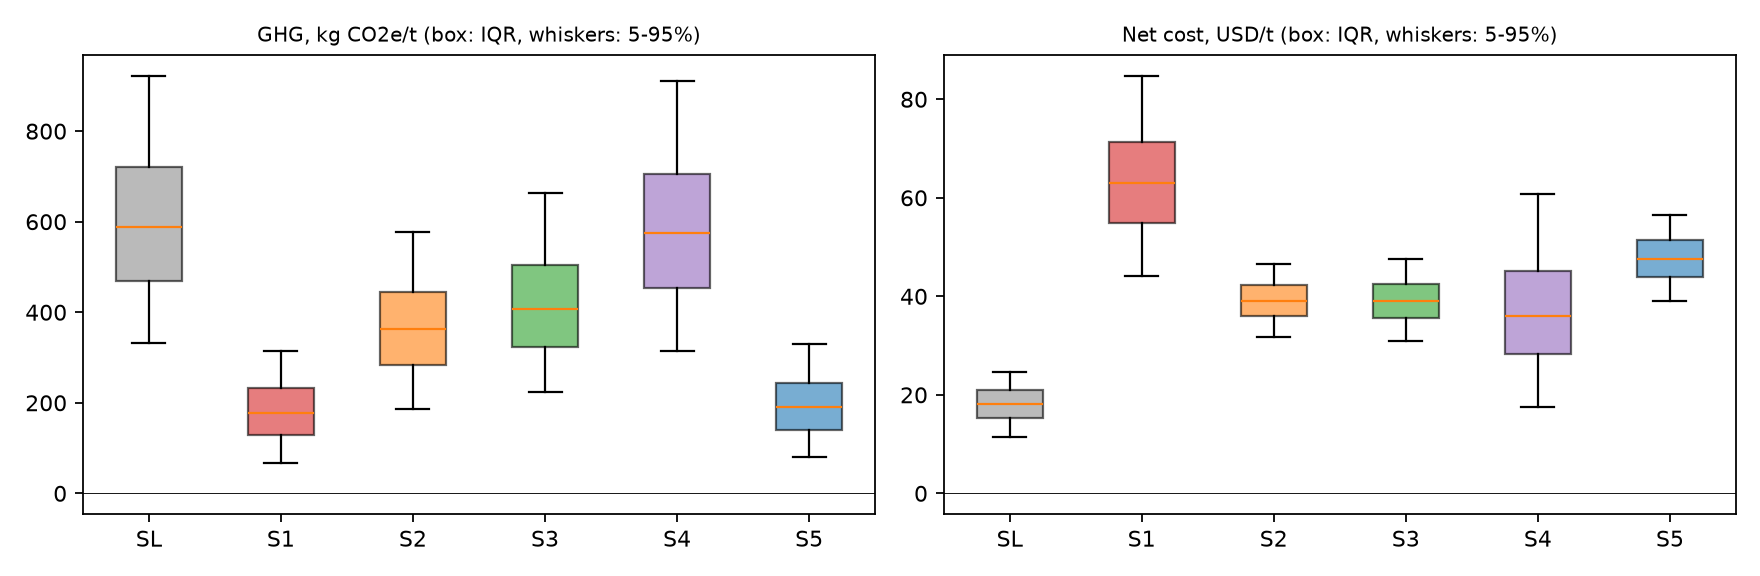

Inputs most correlated with each output (|Spearman rho|):


,output,input,abs_rho
0,SL G,cap,0.82
1,SL G,moisture,0.29
2,SL G,doc_k,0.26
3,SL G,s_garden,0.19
4,SL G,s_plastic,0.16
5,SL G,s_paper,0.11
6,SL C,c_sl,1.00
7,SL C,e_sl,0.08
8,SL C,h_plastic_k,0.04
9,SL C,o_rdf,0.03


In [9]:
display(A["mc"].round(1))
display(Image(str(FIGS["uncertainty"])))
print("Inputs most correlated with each output (|Spearman rho|):")
display(A["spearman"].round(2))

## Step 6. Scenarios and stress tests / Skenario dan uji tekan
Each scenario changes one assumption with the same random numbers. Stress tests push an assumption to its bound:
`moisture_high_bound` (all moistures at their upper value), `rdf_ncv_stress` (RDF energy × 0.78). `phb_large_scale_cost`
is an aspirational what-if, not a planning value.

In [10]:
display(A["scenarios"])

,scenario,central_best_at_0,central_best_at_25,central_best_at_50,central_best_at_100,most_probable_at_25,most_probable_at_50,most_probable_at_100,note
0,market,SL,SL,SL,S5,SL (0.95),SL (0.79),S5 (0.65),NaN
1,perpres109,SL,SL,SL,S5,SL (0.95),SL (0.79),S5 (0.65),NaN
2,food_separated_at_source,SL,S3,S3,S3,S3 (0.51),S3 (0.84),S3 (0.51),NaN
3,AD_feed_optimistic,SL,SL,SL,S5,SL (0.95),SL (0.68),S5 (0.78),NaN
4,residues_to_open_dump,SL,SL,SL,S1,SL (0.82),SL (0.62),S5 (0.51),NaN
5,managed_M1_status_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not applicable (no data for this city)
6,managed_M2_local_first,SL,SL,SL,S5,SL (0.97),SL (0.83),S5 (0.65),NaN
7,GWP20,SL,SL,S1,S1,SL (0.53),S5 (0.49),S1 (0.54),NaN
8,moisture_IPCC_default,SL,SL,S5,S5,SL (0.88),S5 (0.37),S5 (0.66),NaN
9,tonnage_overview_projected,SL,SL,SL,S5,SL (0.95),SL (0.79),S5 (0.65),NaN


## Step 7. Break-even targets against the landfill / Target impas
With all other inputs central, the value of one input at which the option's carbon-inclusive cost equals the
landfill's. *never*: no value in the tested range is enough; *always*: the option is already cheaper over the whole
range. These are targets that a tender, a pilot or an offtake contract would have to secure.

In [11]:
be = A["break_even"]
display(be.pivot_table(index=["option", "input", "better_if", "central_value"], columns="carbon_value",
                       values="break_even", aggfunc="first"))

carbon_value                                           25               50               100
option input      better_if central_value                                                   
S1     K_wte      lower     1.200000e+08   48065475.211056  72601575.248021  121673775.32195
       o_wte      lower     2.700000e+01             never         7.604896        27.684897
       p_el       higher    7.000000e-02          0.151834         0.123921         0.068096
S2     cap        lower     5.000000e-01             never            never         0.534307
       o_rdf      lower     1.840000e+01          3.491637         8.885932        19.674522
       p_rdf      higher    1.150000e+00          4.317821         3.171608         0.879182
S3     cap        lower     5.000000e-01             never            never         0.471057
       o_ad       lower     1.400000e+01             never            never        10.881977
       pre_ofmsw  lower     5.000000e+00             never            never         1.881977
       y_pen_mech higher    6.000000e-01             never            never         0.723927
S5     cap        lower     5.000000e-01             never         0.282072         0.674904
       o_rdf      lower     1.840000e+01          1.541981        11.078627         30.15192
       p_rdf      higher    1.150000e+00          4.764453         2.719743           always
       pre_ofmsw  lower     5.000000e+00             never            never           always
       y_pen_mech higher    6.000000e-01             never            never           always

## Step 8. Value of information: what to measure first / Data apa yang perlu diukur dulu
$EVPI = E[\max_k NB_k] - \max_k E[NB_k]$ with $NB = -CIC$: the most it is worth paying (per tonne) to remove all
uncertainty before choosing. EVPPI is the same for one group of inputs that one measurement campaign would resolve
(regression estimator; the value for random noise is subtracted). Multiplied by the 2025 tonnage it is in USD/year:
if a measurement costs less than its EVPPI for one year, it is worth doing before committing to a technology.

carbon_value,25,50,100
group,,,
"Landfill gas performance (collection, DOC, F, oxidation)",0.0,0.013,0.490
"Waste characterisation (moisture, composition)",0.0,0.052,0.311
WtE performance and cost,0.0,0.004,0.291
"RDF line and off-take (O&M, CAPEX, price, coal substitution, sorting)",0.0,0.006,0.005
"AD on mixed waste (yield, penalty, capture, costs, pre-treatment)",0.0,0.000,0.002
Landfill cost,0.0,0.000,0.000
Grid and electricity price,0.0,0.000,0.000
"Finance (discount rate, lifetime, scale exponent)",0.0,0.000,0.000


EVPI (USD/t and USD/yr):


,evpi,evpi_usd_per_year
carbon_value,,
25,0.21,49203.46
50,1.14,273285.32
100,3.00,717681.01


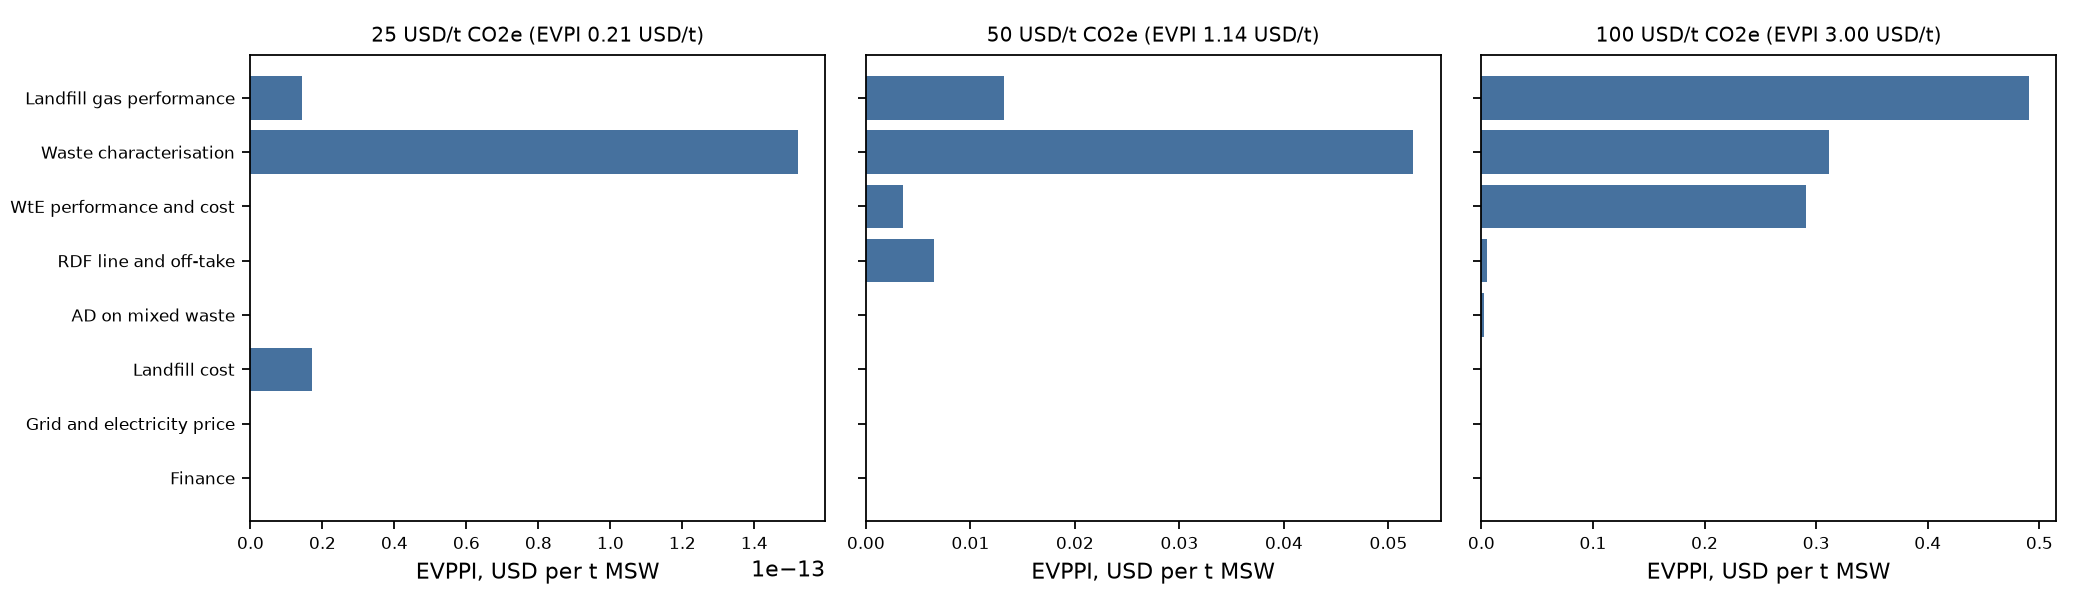

In [12]:
vg = A["voi_groups"]
display(vg.pivot_table(index="group", columns="carbon_value", values="evppi_net").sort_values(100, ascending=False).round(3))
print("EVPI (USD/t and USD/yr):"); display(vg.groupby("carbon_value")[["evpi", "evpi_usd_per_year"]].first().round(2))
display(Image(str(FIGS["voi"])))

## Step 9. Projection to 2045 / Proyeksi 2045 terhadap kondisi 2025
The same city in 2045, compared with the existing condition of 2025. Drivers (edit `data/projection_2045_parameters.csv`
or the cell below):

* **Grid**: $EF_{grid}(t) = EF_{grid}(2025)\,\max[0,\,1-\delta (t-2025)]$ with $\delta = 1/35$ per year (linear path to
  a net-zero grid in 2060), so $EF_{grid}(2045) = 0.429\,EF_{grid}(2025)$;
* **Real escalation** $x(t) = x(2025)(1+e)^{t-2025}$: electricity value 2%/yr, labour-driven O&M 1%/yr,
  landfill cost 2%/yr; CAPEX constant in real terms;
* **Tonnage**: $Q(t) = Q(2025)(1+g)^{t-2025}$; composition held constant.

Your local parameter values are read as 2025 values and escalated like the defaults. Each driver is also run alone
(decomposition), and the Monte Carlo draws are paired between the two years.

{'delta_grid': 0.02857142857142857, 'esc_electricity': 0.02, 'esc_labour': 0.01, 'esc_landfill': 0.02, 'netzero_year': 2060.0}


Factors 2025 -> 2045


year                     2045.000
years                      20.000
grid_factor                 0.429
f_el                        1.486
f_lab                       1.220
f_lf                        1.486
tonnage_factor_median       1.138
dtype: float64

Central results per tonne, 2025 vs 2045


,G_2025,G_2045,C_2025,C_2045,CED_2025,CED_2045,avoided_vs_SL_2025,avoided_vs_SL_2045,MAC_vs_SL_2025,MAC_vs_SL_2045,G_change,C_change
pathway,,,,,,,,,,,,
SL,561.15,561.15,18.44,26.35,77.60,77.60,0.00,0.00,NaN,NaN,0.00,7.91
S1,159.55,330.56,57.91,52.75,-4195.68,-1698.38,401.60,230.59,98.29,114.48,171.01,-5.16
S2,345.38,326.36,38.74,48.19,-3857.64,-4135.35,215.77,234.79,94.09,93.03,-19.02,9.45
S3,389.49,400.76,36.57,43.86,-196.71,-32.07,171.66,160.39,105.63,109.16,11.27,7.29
S4,547.22,547.22,38.07,45.35,-580.02,-580.02,13.93,13.93,1409.63,1363.98,0.00,7.28
S5,179.68,179.55,44.83,52.20,-4302.90,-4304.89,381.47,381.60,69.19,67.74,-0.14,7.37


...

C                                       G                               
        costs only grid only tonnage only total costs only grid only tonnage only   total
pathway                                                                                  
SL            8.96       0.0        -0.70  7.91        0.0      0.00          0.0    0.00
S1           -2.90       0.0        -2.14 -5.16        0.0    171.01          0.0  171.01
S2           10.67       0.0        -0.97  9.45        0.0    -19.02          0.0  -19.02
S3            8.56       0.0        -1.00  7.29        0.0     11.27          0.0   11.27
S4            8.96       0.0        -1.34  7.28        0.0      0.00          0.0    0.00
S5            8.63       0.0        -1.08  7.37        0.0     -0.14         -0.0   -0.14

Uncertainty of the change (paired Monte Carlo, p5 / p50 / p95):


,option,indicator,p5,p50,p95
0,SL,G,-0.0,0.0,0.0
1,SL,C,4.9,7.8,10.6
2,S1,G,109.0,161.6,232.0
3,S1,C,-12.5,-5.9,-0.9
4,S2,G,-27.9,-18.9,-11.6
5,S2,C,7.0,9.4,11.7
6,S3,G,1.2,9.5,21.4
7,S3,C,4.8,7.4,10.0
8,S4,G,-0.0,0.0,0.0
9,S4,C,4.2,7.1,9.9


Preferred option at fixed carbon values:


,year,carbon_value,most_probable,p,P(SL),P(S1),P(S2),P(S3),P(S4),P(S5)
0,2025,0,SL,0.958,0.958,0.000,0.000,0.000,0.042,0.000
1,2025,2,SL,0.958,0.958,0.000,0.000,0.000,0.042,0.000
2,2025,25,SL,0.950,0.950,0.003,0.000,0.000,0.046,0.001
3,2025,50,SL,0.795,0.795,0.043,0.012,0.002,0.047,0.102
4,2025,100,S5,0.653,0.197,0.116,0.006,0.006,0.020,0.653
5,2045,0,SL,0.934,0.934,0.018,0.000,0.000,0.048,0.000
6,2045,2,SL,0.933,0.933,0.018,0.000,0.000,0.048,0.000
7,2045,25,SL,0.900,0.900,0.044,0.001,0.000,0.054,0.002
8,2045,50,SL,0.734,0.734,0.098,0.007,0.002,0.054,0.106
9,2045,100,S5,0.691,0.189,0.085,0.008,0.005,0.023,0.691


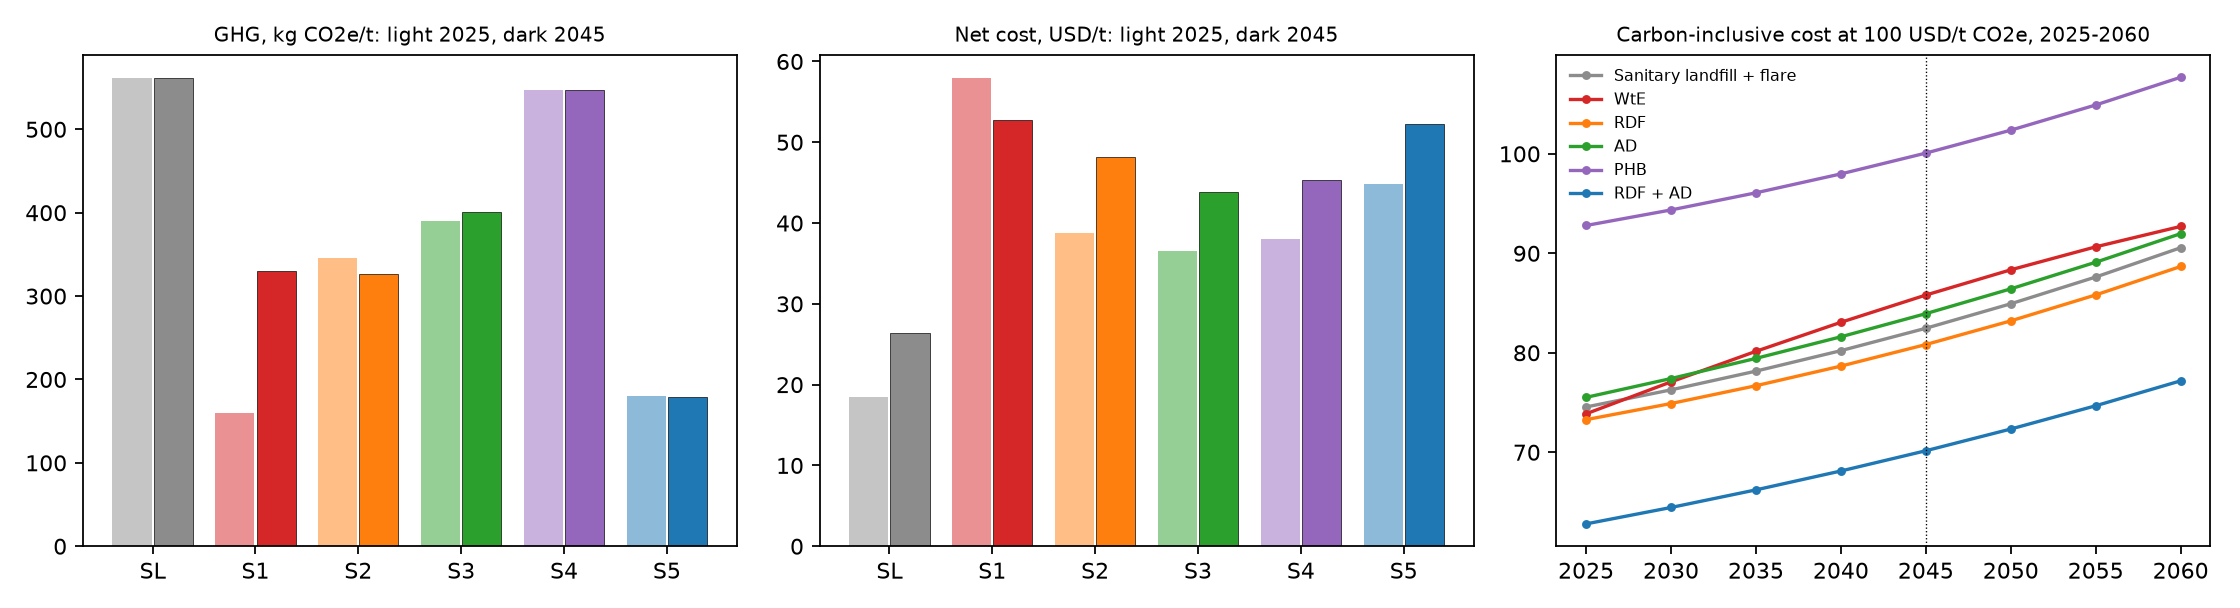

In [13]:
from mswpath.projection import read_parameters
PROJ_YEAR = 2045
pr = read_parameters("data"); print({k: pr[k] for k in ("delta_grid", "esc_electricity", "esc_labour", "esc_landfill", "netzero_year")})
PJ = S.project_city("data", raw, par, seed=SEED, N=N, year=PROJ_YEAR)
print("Factors 2025 ->", PROJ_YEAR); display(PJ["factors"].round(3))
print("Central results per tonne, 2025 vs", PROJ_YEAR); display(PJ["central"].round(2))
print("Change by driver (each applied alone):"); display(PJ["decomposition"].round(2))
print("Uncertainty of the change (paired Monte Carlo, p5 / p50 / p95):"); display(PJ["change_uncertainty"].round(1))
print("Preferred option at fixed carbon values:"); display(PJ["p_best"].round(3))
FIGS["projection"] = S.projection_figure(PJ, OUT); display(Image(str(FIGS["projection"])))

## Step 10. Download the reports / Unduh laporan

In [14]:
safe = "".join(ch if ch.isalnum() else "_" for ch in A["city"]).strip("_")
rep = S.write_report(A, OUT / f"report_{safe}.xlsx", inputs=raw, warnings=warnings, overrides=changed)
rep2 = S.write_projection_report(PJ, OUT / f"projection_{PROJ_YEAR}_{safe}.xlsx")
import shutil; z = shutil.make_archive(str(OUT / f"results_{safe}"), "zip", OUT)
print("Written:", rep, rep2, "and", z)
if IN_COLAB:
    from google.colab import files; files.download(str(rep)); files.download(str(rep2)); files.download(z)

Written: outputs/single_city/report_Kota_Padang.xlsx outputs/single_city/projection_2045_Kota_Padang.xlsx and /home/user/claude/MSW_pathway_model_v3/outputs/single_city/results_Kota_Padang.zip


## Caveats and citation / Catatan dan sitasi
* Screening (ex-ante) LCA/TEA with class-5 costs: use it to decide which options to study further, not as a design.
* The composition is the sampling-year composition used as a 2025 proxy; categories left blank are not reported and
  get zero share (a stated assumption).
* Default parameters, their sources and evidence status are in `data/assumption_register.csv`,
  `data/scenario_parameters.csv` and `data/secondary_data_verification.csv`. Values you enter in `local_parameters`
  replace them and are listed in the report.
* The carbon-inclusive cost values only greenhouse gases; health and local pollution are not valued.
* With the example data and the default seed, this notebook reproduces the Kota Padang results of the article.

Cite: Ridwan, M.F., Halog, A. (2026). *mswpath: provenance-aware screening of MSW recovery pathways for Indonesian
cities*, v3.2 (see `CITATION.cff`). Methodology: `docs/MSW_Methodology_v3_EN.pdf`; worked example:
`docs/Worked_Example_Kota_Padang_EN.pdf`.